In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
%run db.py

In [10]:
# Set the artist name to analyze
artist = ''

In [27]:
def get_artist_songs(artist, min_cnt=40):
    """Get all songs for an artist with at least min_cnt ratings."""
    sql = '''select c.id,ps.artist_id,artist,title,num_dislikes+num_likes+num_superlikes as cnt
        from piki_score ps inner join catalog c on ps.song_id=c.id
         where artist='%s' and 
         num_dislikes+num_likes+num_superlikes > %s''' % (str(artist), str(min_cnt))
    songs = DB.fetch(sql)
    return songs


def get_likes_for_song(song_id):
    """Get all likes/dislikes for a song in chronological order."""
    sql = '''select * from (
        select us.timestamp, 1 as pick from user_songs us
        inner join users u on us.user_id = u.id
        where u.type = 1 and seq = 0 and song_id = %s
        union
        select us.timestamp, 2 as pick from user_songs us
        inner join users u on us.user_id = u.id
        where u.type = 1 and seq = 2 and song_id = %s
        union
        select timestamp, 0 as pick from unliked_songs
        where song_id = %s
    ) t order by timestamp asc''' % (str(song_id), str(song_id), str(song_id))
    rows = DB.fetch(sql)
    # treat superlike (2) as like (1)
    picks = [(1 if row['pick'] > 0 else 0) for row in rows]
    return picks


def get_song_title(song_id):
    sql = 'select title from catalog where id = %s' % str(song_id)
    row = DB.fetch_one(sql)
    return row['title']

In [29]:
def plot_song_plike(song_id, title, prior_likes=10, prior_dislikes=20):
    """Plot cumulative p(like) over number of ratings for a single song."""
    picks = get_likes_for_song(song_id)
    if len(picks) == 0:
        return
    likes_cumsum = np.cumsum(picks)
    total = np.arange(1, len(picks) + 1)
    pct = (likes_cumsum + prior_likes) / (total + prior_likes + prior_dislikes)
    # prepend the prior
    pct = np.insert(pct, 0, prior_likes / (prior_likes + prior_dislikes))
    plt.plot(pct * 100, label=title, linewidth=2)

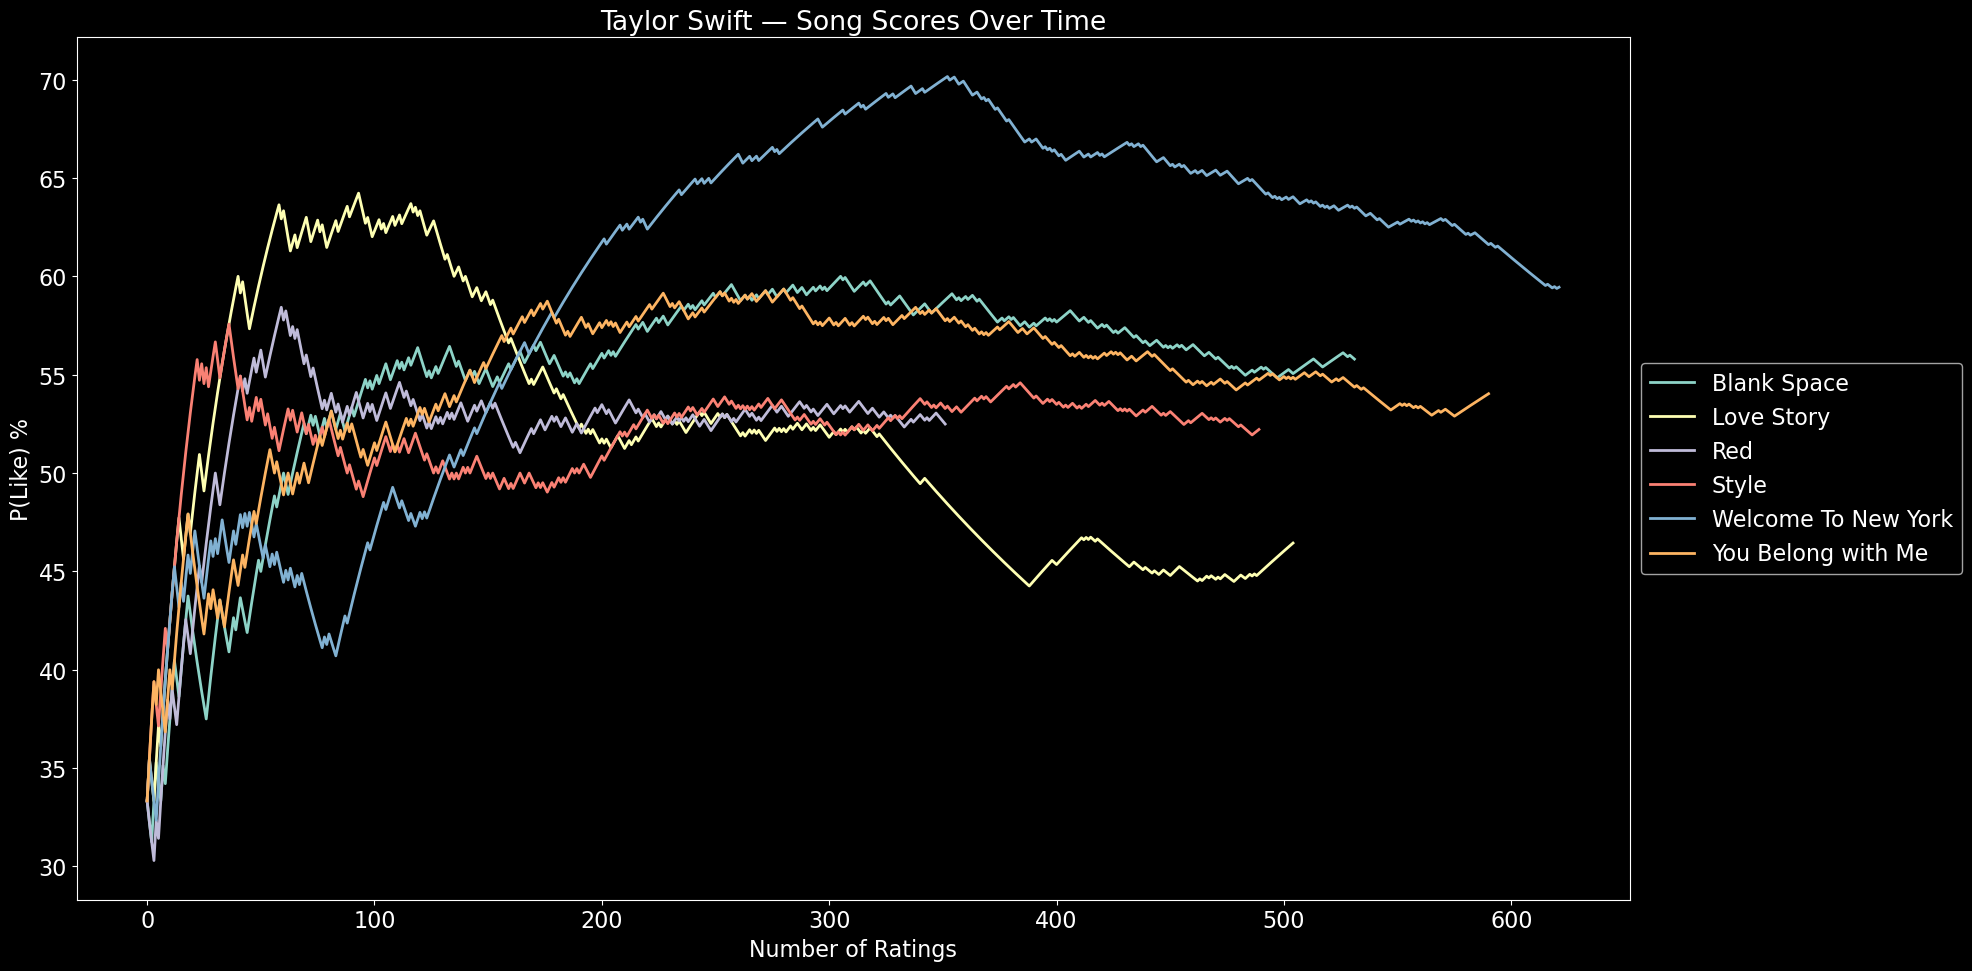

In [31]:
plt.style.use(['dark_background'])
plt.rcParams['figure.figsize'] = [20, 10]
plt.rcParams.update({'font.size': 16})

songs = get_artist_songs(artist, min_cnt=400)

for song in songs:
    plot_song_plike(song['id'], song['title'])

plt.xlabel('Number of Ratings')
plt.ylabel('P(Like) %')
plt.title(f'{artist} — Song Scores Over Time')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()